# Análisis del Uso del Tiempo — Ciudad de Buenos Aires (2016)
**Autor:** Ignacio Javier D'Amico  
**Fuente:** Encuesta de Uso del Tiempo 2016 — Dirección General de Estadística y Censos, GCBA  
**Dataset:** [Buenos Aires Data](https://data.buenosaires.gob.ar/)  
**Herramientas:** Python · Pandas · Matplotlib · Seaborn

---

## Objetivo

Analizar cómo se distribuye el tiempo dedicado al **trabajo remunerado** y al **trabajo reproductivo** (doméstico y de cuidados) según el **sexo** y el **rango etario** de los habitantes de CABA, con el fin de identificar desigualdades de género en la división social del trabajo.

## Hipótesis

> Las mujeres dedican más tiempo al trabajo reproductivo que los varones del mismo rango etario, generando una **doble carga laboral** que no es visible cuando solo se mide el trabajo remunerado.

---

## Nota metodológica: simultaneidad

La encuesta registra dos mediciones del tiempo:

- **Con simultaneidad:** si dos actividades ocurren al mismo tiempo, ambas reciben el tiempo completo. La suma puede superar las 24 horas. Refleja mejor la **carga real** de trabajo.
- **Sin simultaneidad:** el tiempo se divide proporcionalmente entre actividades paralelas. La suma siempre es 24 horas. Refleja la **distribución del día**.

Esta distinción es clave para visualizar la doble carga laboral de las mujeres.

## 1. Importación de librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores consistente en todo el análisis
COLOR_MUJER = '#C2478A'
COLOR_VARON = '#2E6DA4'
BG          = '#F8F9FA'
GRID_COLOR  = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.grid':         True,
    'grid.color':        GRID_COLOR,
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
})

## 2. Carga y preparación de datos

In [7]:
# Carga del dataset
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQuFBnI-xN2DnCcZHctbDwKtnzeP68i0BXb7M6j-iORk-NCKivqIDFJ5ik5Rtq2bas7O8AbLMKxyfo-/pub?gid=180127333&single=true&output=csv')                               

print(f'Registros: {df.shape[0]} | Variables: {df.shape[1]}')
df.head(3)

Registros: 2336 | Variables: 29


,hogar,codigo_sexo,sexo,edad,dia_laborable,trabajo_pago,trabajo_domestico_no_pago,voluntariados,estudio_educacion,recreacion,...,tareas_cuidados2,cuidado_personal2,dia_tipico,rango_etario,Codigo_nivel_educativo,nivel_educativo,relacion_parentesco_jefe,tipo_hogar,quintil_ingreso,estado_ocupacional
0,1_1,2,Varon,14,Día no laborable,0.0,0.1,0.0,0.0,9.0,...,0.0,7.9,Día atípico,14-24,3,Secundario incompleto,Hijo/a - Hijastro/a,Nuclear con nucleo incompleto,5to quintil,Inactivo
1,2_1,2,Varon,14,Día no laborable,0.0,1.0,0.0,8.3,2.7,...,0.0,9.8,Día atípico,14-24,3,Secundario incompleto,Hijo/a - Hijastro/a,Nuclear con nucleo completo,5to quintil,Inactivo
2,3_1,2,Varon,14,Día no laborable,0.0,0.2,0.0,11.3,2.6,...,0.0,10.1,Día atípico,14-24,3,Secundario incompleto,Hijo/a - Hijastro/a,Nuclear con nucleo completo,5to quintil,Inactivo


In [11]:
# Verificación de valores nulos — el dataset ya viene procesado
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [13]:
# Construcción de variables derivadas
# Trabajo reproductivo = doméstico no pago + tareas de cuidado
df['trabajo_reproductivo_sim']   = df['trabajo_domestico_no_pago'] + df['tareas_cuidados']
df['trabajo_reproductivo_nosim'] = df['trabajo_domestico_no_pago2'] + df['tareas_cuidados2']

# Trabajo total = remunerado + reproductivo
df['trabajo_total_sim']   = df['trabajo_pago']  + df['trabajo_reproductivo_sim']
df['trabajo_total_nosim'] = df['trabajo_pago2'] + df['trabajo_reproductivo_nosim']

# Intervalos de horas para análisis de distribución
bins   = [0, 1, 3, 5, 7, 9, 11, 15, 30]
labels = ['0', '1-2', '3-4', '5-6', '7-8', '9-10', '11-14', '15+']
df['intervalo_horaspagas']        = pd.cut(df['trabajo_pago'],             bins=bins, labels=labels, include_lowest=True)
df['intervalo_horasreproductivo'] = pd.cut(df['trabajo_reproductivo_sim'], bins=bins, labels=labels, include_lowest=True)

print('Variables derivadas creadas correctamente.')

Variables derivadas creadas correctamente.


## 3. Exploración de la muestra

In [15]:
# Composición de la muestra
print('Distribución por sexo:')
print(df['sexo'].value_counts())
print()
print('Distribución por rango etario:')
print(df['rango_etario'].value_counts().sort_index())
print()
print('Distribución por tipo de día:')
print(df['dia_laborable'].value_counts())

Distribución por sexo:
sexo
Mujer    1345
Varon     991
Name: count, dtype: int64

Distribución por rango etario:
rango_etario
14-24    291
25-39    672
40-49    307
50-64    521
65+      545
Name: count, dtype: int64

Distribución por tipo de día:
dia_laborable
Día no laborable    1214
Día laborable       1122
Name: count, dtype: int64


## 4. Resultados

### 4.1 Distribución del trabajo total según sexo

El siguiente gráfico muestra el **volumen total de horas trabajadas** (remuneradas + reproductivas) acumuladas por la muestra, desagregado por sexo. Se presentan ambas mediciones para evidenciar cómo la simultaneidad amplifica la brecha de género.

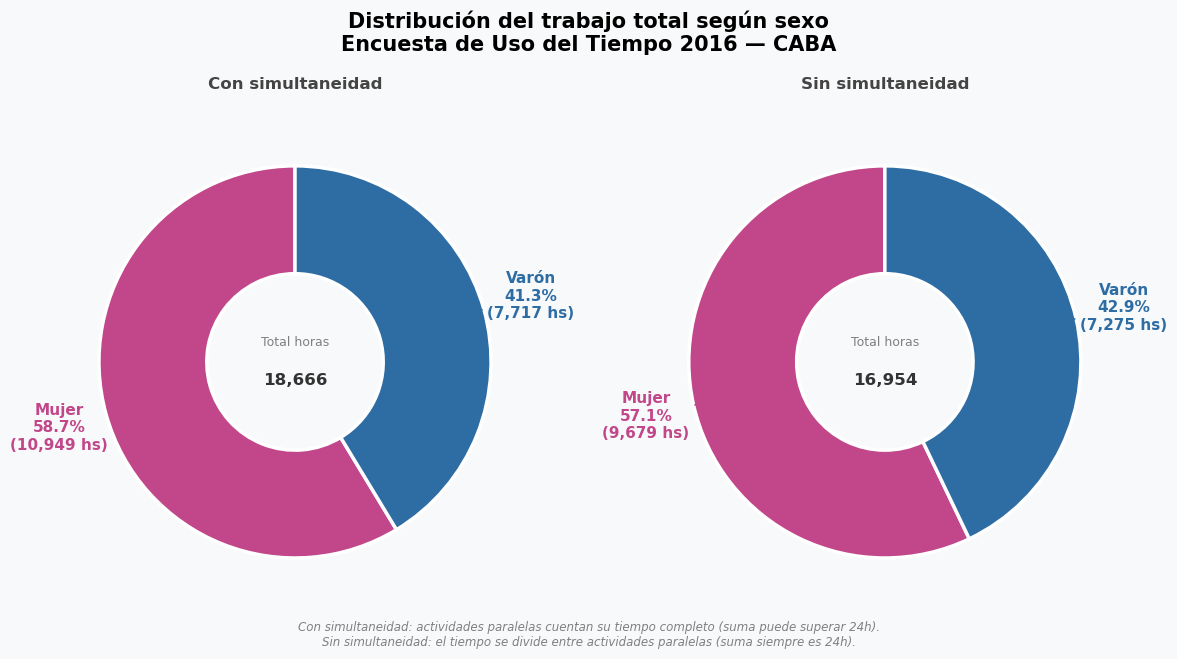

In [17]:
sumas_sim   = df.groupby('sexo')['trabajo_total_sim'].sum()
sumas_nosim = df.groupby('sexo')['trabajo_total_nosim'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Distribución del trabajo total según sexo\nEncuesta de Uso del Tiempo 2016 — CABA',
    fontsize=15, fontweight='bold', y=1.02
)

for ax, sumas, titulo in zip(
    axes,
    [sumas_sim, sumas_nosim],
    ['Con simultaneidad', 'Sin simultaneidad']
):
    valores = [sumas['Mujer'], sumas['Varon']]
    total   = sum(valores)
    pcts    = [v/total*100 for v in valores]
    colors  = [COLOR_MUJER, COLOR_VARON]
    labels  = ['Mujer', 'Varón']

    wedges, _ = ax.pie(
        valores, colors=colors, startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
    )
    for i, (wedge, pct, val) in enumerate(zip(wedges, pcts, valores)):
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = np.cos(np.radians(angle))
        y = np.sin(np.radians(angle))
        ax.annotate(
            f'{labels[i]}\n{pct:.1f}%\n({val:,.0f} hs)',
            xy=(x*0.75, y*0.75), xytext=(x*1.25, y*1.25),
            fontsize=11, fontweight='bold', color=colors[i], ha='center', va='center',
            arrowprops=dict(arrowstyle='-', color=colors[i], lw=1.2),
        )
    ax.text(0, 0.08, 'Total horas', ha='center', fontsize=9, color='gray')
    ax.text(0, -0.12, f'{total:,.0f}', ha='center', fontsize=12, fontweight='bold', color='#333')
    ax.set_title(titulo, fontsize=12, pad=20, color='#444')

fig.text(0.5, -0.04,
    'Con simultaneidad: actividades paralelas cuentan su tiempo completo (suma puede superar 24h).\n'
    'Sin simultaneidad: el tiempo se divide entre actividades paralelas (suma siempre es 24h).',
    ha='center', fontsize=8.5, color='gray', style='italic')

plt.tight_layout()
plt.savefig('fig_torta_trabajo_total.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Desagregación: trabajo remunerado vs reproductivo

Promedio de horas diarias por tipo de trabajo y sexo. La comparación con/sin simultaneidad revela que la brecha se amplía cuando se considera que las mujeres realizan múltiples tareas en simultáneo.

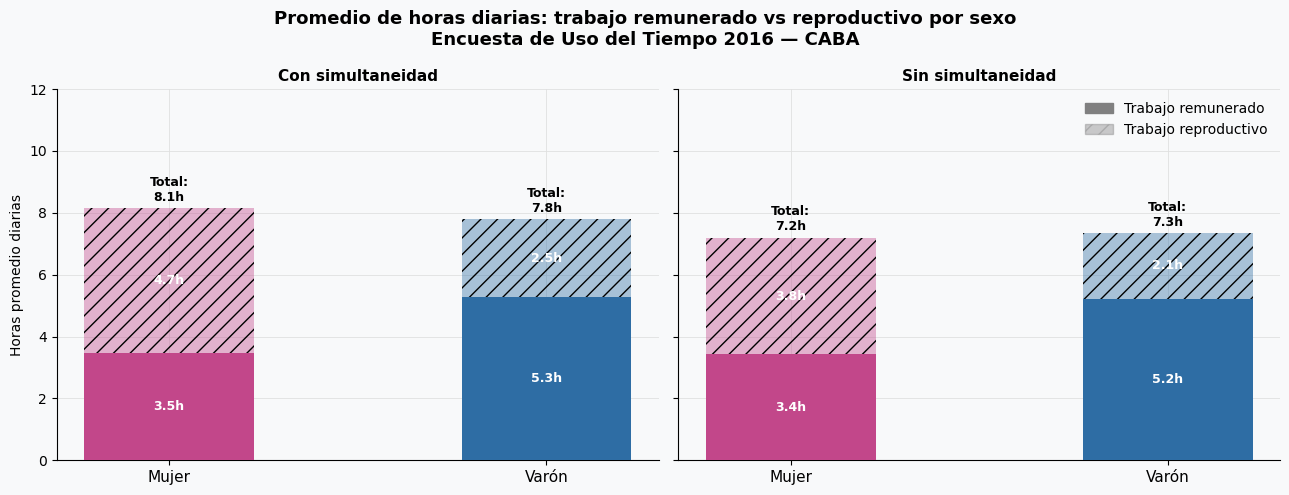

In [19]:
cols_sim   = ['trabajo_pago',  'trabajo_reproductivo_sim']
cols_nosim = ['trabajo_pago2', 'trabajo_reproductivo_nosim']
med_sim    = df.groupby('sexo')[cols_sim].mean()
med_nosim  = df.groupby('sexo')[cols_nosim].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    'Promedio de horas diarias: trabajo remunerado vs reproductivo por sexo\n'
    'Encuesta de Uso del Tiempo 2016 — CABA',
    fontsize=13, fontweight='bold'
)

for ax, med, cols, titulo in zip(
    axes,
    [med_sim, med_nosim],
    [cols_sim, cols_nosim],
    ['Con simultaneidad', 'Sin simultaneidad']
):
    rem   = [med.loc['Mujer', cols[0]], med.loc['Varon', cols[0]]]
    repro = [med.loc['Mujer', cols[1]], med.loc['Varon', cols[1]]]
    colors = [COLOR_MUJER, COLOR_VARON]

    ax.bar([0,1], rem,   0.45, color=colors, zorder=3)
    ax.bar([0,1], repro, 0.45, bottom=rem, color=colors, alpha=0.4, hatch='//', zorder=3)

    for i, (r, rp) in enumerate(zip(rem, repro)):
        ax.text(i, r/2,      f'{r:.1f}h',          ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        ax.text(i, r+rp/2,   f'{rp:.1f}h',         ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        ax.text(i, r+rp+0.15, f'Total:\n{r+rp:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks([0,1])
    ax.set_xticklabels(['Mujer','Varón'], fontsize=11)
    ax.set_title(titulo, fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Horas promedio diarias')

patch1 = mpatches.Patch(color='gray',             label='Trabajo remunerado')
patch2 = mpatches.Patch(color='gray', alpha=0.4, hatch='//', label='Trabajo reproductivo')
axes[1].legend(handles=[patch1, patch2], frameon=False)
axes[0].set_ylim(0, 12)
plt.tight_layout()
plt.savefig('fig_desagregacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Tasas de participación

La tasa de participación indica qué proporción de cada grupo dedica tiempo a esa actividad. Permite distinguir entre **quiénes participan** y **cuánto tiempo destinan** quienes participan.

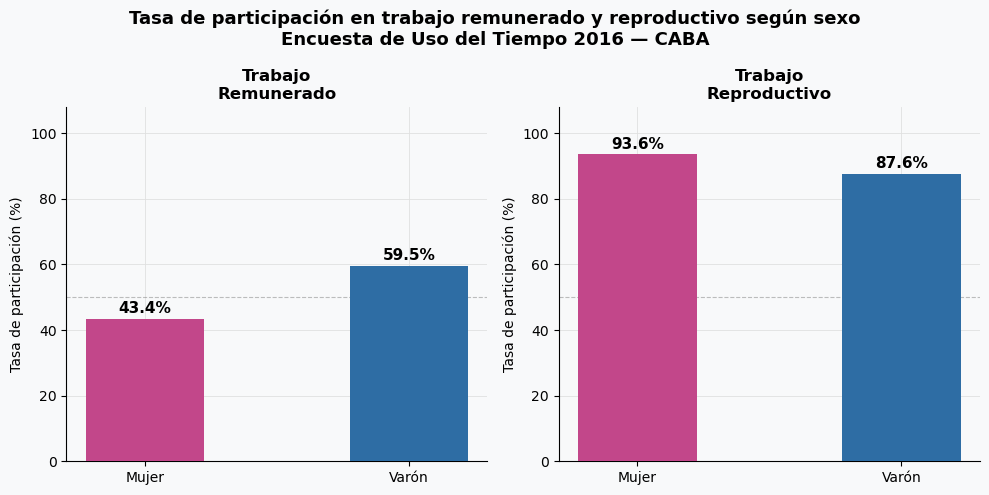

In [21]:
total_m = df[df['sexo']=='Mujer'].shape[0]
total_v = df[df['sexo']=='Varon'].shape[0]

tasas = {
    'Trabajo\nRemunerado': {
        'Mujer': df[(df['sexo']=='Mujer') & (df['trabajo_pago']>0)].shape[0] / total_m * 100,
        'Varón': df[(df['sexo']=='Varon') & (df['trabajo_pago']>0)].shape[0] / total_v * 100,
    },
    'Trabajo\nReproductivo': {
        'Mujer': df[(df['sexo']=='Mujer') & (df['trabajo_reproductivo_sim']>0)].shape[0] / total_m * 100,
        'Varón': df[(df['sexo']=='Varon') & (df['trabajo_reproductivo_sim']>0)].shape[0] / total_v * 100,
    },
}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(
    'Tasa de participación en trabajo remunerado y reproductivo según sexo\n'
    'Encuesta de Uso del Tiempo 2016 — CABA',
    fontsize=13, fontweight='bold'
)

for ax, (tipo, vals) in zip(axes, tasas.items()):
    values = [vals['Mujer'], vals['Varón']]
    bars = ax.bar(['Mujer','Varón'], values, color=[COLOR_MUJER, COLOR_VARON], width=0.45, zorder=3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(tipo, fontsize=12)
    ax.set_ylabel('Tasa de participación (%)')
    ax.set_ylim(0, 108)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('fig_tasas.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Trabajo reproductivo por rango etario — días laborables

El análisis por rango etario permite identificar en qué etapas de la vida se concentra la desigualdad. El perfil más afectado son las **mujeres de 25 a 49 años**, que combinan mayor carga de cuidados con participación activa en el mercado laboral.

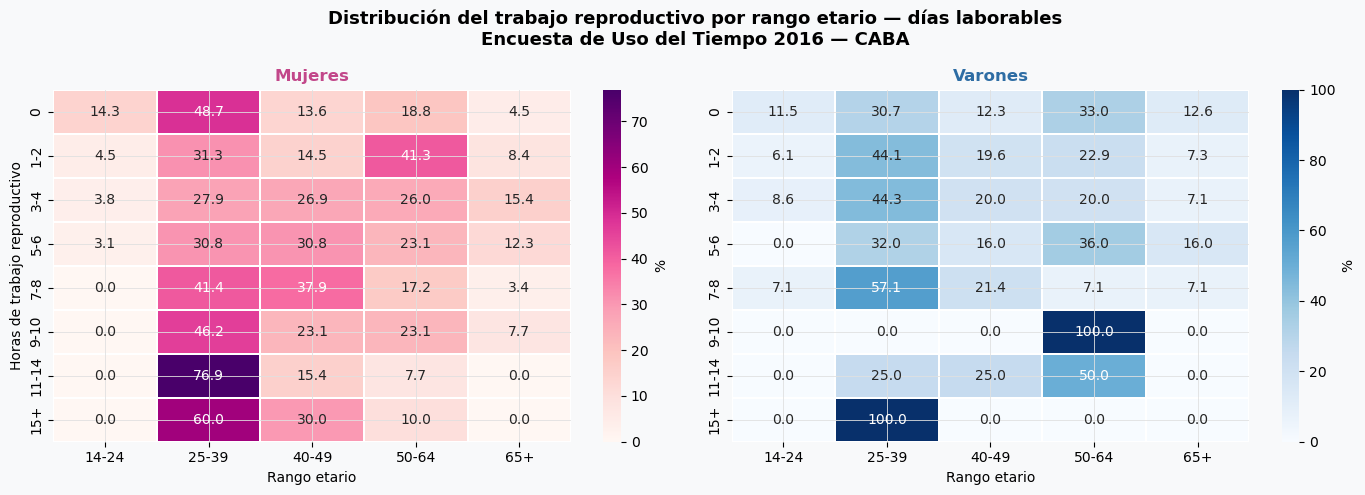

In [23]:
orden_etario = ['14-24', '25-39', '40-49', '50-64', '65+']
muj_lab = df[(df['sexo']=='Mujer') & (df['dia_laborable']=='Día laborable')]
var_lab = df[(df['sexo']=='Varon') & (df['dia_laborable']=='Día laborable')]

hm_m = pd.crosstab(muj_lab['intervalo_horasreproductivo'], muj_lab['rango_etario'], normalize='index') * 100
hm_v = pd.crosstab(var_lab['intervalo_horasreproductivo'], var_lab['rango_etario'], normalize='index') * 100
hm_m = hm_m.reindex(columns=orden_etario, fill_value=0)
hm_v = hm_v.reindex(columns=orden_etario, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Distribución del trabajo reproductivo por rango etario — días laborables\n'
    'Encuesta de Uso del Tiempo 2016 — CABA',
    fontsize=13, fontweight='bold'
)

sns.heatmap(hm_m, ax=axes[0], annot=True, fmt='.1f', cmap='RdPu',
            cbar_kws={'label': '%'}, linewidths=0.3)
axes[0].set_title('Mujeres', fontsize=12, color=COLOR_MUJER, fontweight='bold')
axes[0].set_xlabel('Rango etario')
axes[0].set_ylabel('Horas de trabajo reproductivo')

sns.heatmap(hm_v, ax=axes[1], annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': '%'}, linewidths=0.3)
axes[1].set_title('Varones', fontsize=12, color=COLOR_VARON, fontweight='bold')
axes[1].set_xlabel('Rango etario')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Conclusiones

El análisis confirma la hipótesis planteada:

- **Las mujeres concentran el 58.6% del trabajo total** (con simultaneidad) a pesar de representar el 57.6% de la muestra, lo que indica una carga proporcionalmente mayor.
- **La tasa de participación en trabajo reproductivo** es del 93.6% en mujeres versus 87.5% en varones — prácticamente universal en las mujeres.
- **La simultaneidad amplifica la brecha:** al considerar que las mujeres realizan múltiples tareas de cuidado en paralelo, su carga real supera la que se observa sin esa medición.
- **El perfil más afectado** son las mujeres de 25 a 49 años, que concentran la mayor carga reproductiva durante los mismos años en que participan activamente en el mercado laboral.
- **En varones**, la dedicación al trabajo reproductivo tiende a concentrarse en 0 horas, especialmente en los rangos etarios extremos.

Estos hallazgos subrayan la importancia de las encuestas de uso del tiempo como herramienta para **visibilizar desigualdades de género** que no son captadas por las estadísticas tradicionales del mercado laboral, y su utilidad para el diseño de políticas públicas orientadas a redistribuir la carga del trabajo reproductivo.

---

## Referencias

- Dirección General de Estadística y Censos GCBA (2017). *Encuesta de Uso del Tiempo 2016*. Buenos Aires Data.
- Carrasquer, P. (1998). El trabajo reproductivo. *Sociología del Trabajo*, 33.
- INDEC (2021). *Manual de la Encuesta sobre Trabajo No Remunerado y Uso del Tiempo*.